<a href="https://colab.research.google.com/github/yihui1227/MMIP/blob/main/MMIP_HW2_315832025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quiz 1 機器學習分類任務

> 資料集：[Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


**目標**： 預測顧客是否流失(Churn),並比較不同 Threshold 與不同模型的表現


## 0. 環境設定與資料集準備



In [3]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, fbeta_score,
)

try:
    from IPython.display import display
except ImportError:          # 不在 notebook 環境時退回 print
    display = print

RANDOM_STATE   = 42   # 【可調整】固定亂數種子,讓結果可重現

In [4]:
CSV_NAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

def find_csv():
    # 方式 1:kagglehub
    try:
        try:
            import kagglehub
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
            import kagglehub
        folder = kagglehub.dataset_download("blastchar/telco-customer-churn")
        found = glob.glob(os.path.join(folder, "*.csv"))
        if found:
            print("kagglehub 下載成功:", found[0])
            return found[0]
    except Exception as e:
        print("kagglehub 下載失敗,改用手動上傳。原因:", repr(e)[:200])
    # 方式 2:手動上傳
    from google.colab import files
    uploaded = files.upload()
    return list(uploaded.keys())[0]

df = find_csv()
df = pd.read_csv(df)
print("\n資料形狀:", df.shape)
display(df.head())

100%|██████████| 172k/172k [00:00<00:00, 335kB/s]

Extracting files...
kagglehub 下載成功: /root/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv

資料形狀: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# 檢查各欄位是否有缺失值
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 1. 資料清理與前處理

這份資料集有幾個點需要注意:

- `TotalCharges` 欄位型別是 object(字串),因為有些是空白字串,因此需要轉成數值並處理缺失值
- `customerID` 是識別碼,對預測沒有幫助,需要移除
- 目標欄位 `Churn` 是 `Yes` / `No`，需轉換成 0/1
- 其餘類別型欄位(如 gender、Contract、PaymentMethod 等)需要做 One-Hot Encoding


In [7]:
# 轉換 TotalCharges 為數值(空白字串會變成 NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 可調整:這裡示範用「該欄位中位數」補值,也可以選擇直接刪除這些列(通常只有極少數)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 移除識別碼欄位
df = df.drop(columns=["customerID"])

# 目標欄位轉換為 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("流失比例(1=流失):")
print(df["Churn"].value_counts(normalize=True))


流失比例(1=流失):
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [8]:
# 類別型欄位 One-Hot Encoding(drop_first=True 避免虛擬變數陷阱,可依需求調整)
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("類別型欄位:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.shape


類別型欄位: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


(7043, 31)

## 2. 切分 Training / Validation Dataset

- 使用 `train_test_split`,並以 `stratify=y` 確保 Train/Validation 中流失比例一致(因為此資料集類別不平衡) (churn的比例不平衡)
- `test_size` 可依需求調整(常見為 0.2 ~ 0.3)。


In [9]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,        # 可調整:驗證集比例
    random_state=RANDOM_STATE,
    stratify=y            # 保持流失比例一致
)

print("Train 筆數:", X_train.shape[0], " Validation 筆數:", X_val.shape[0])


Train 筆數: 5634  Validation 筆數: 1409


## 3. Feature Scaling(特徵縮放)

這裡使用 `StandardScaler`(標準化,平均值 0、標準差 1)。也可以改用 `MinMaxScaler`(可調整)。

**重要**: Scaler 只能用 Training Data 去 `fit`,再用同一個 scaler 去 `transform` Validation Data, 避免 data leakage


In [10]:
# from sklearn.preprocessing import MinMaxScaler
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]  # 可調整:是否要把其他 0/1 欄位也一併標準化

scaler = StandardScaler()  # 可調整:改成 MinMaxScaler() 試試看差異

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])

X_train_scaled[numeric_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,-3.783508e-18
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.002135e+00
25%,-9.559779e-01,-9.711977e-01,-8.309023e-01
50%,-1.418632e-01,1.848336e-01,-3.968393e-01
75%,9.164859e-01,8.319124e-01,6.737360e-01
max,1.608483e+00,1.785939e+00,2.802714e+00


## 4. 模型一： Logistic Regression

Logistic Regression 適合當作 baseline,且天生輸出機率,方便後續調整 Threshold。


In [11]:
model_lr = LogisticRegression(
    max_iter=1000,        # 可調整
    random_state=RANDOM_STATE
)
model_lr.fit(X_train_scaled, y_train)

# 取得驗證集上「屬於流失(1)」的機率
proba_lr = model_lr.predict_proba(X_val_scaled)[:, 1]
proba_lr[:10]


array([0.04492956, 0.68289026, 0.05976384, 0.39909955, 0.02150169,
       0.60242735, 0.44895396, 0.12906434, 0.00291399, 0.39574894])

## 5. 建立 Confusion Matrix 與評估指標

先定義一個共用函式，之後兩個模型、不同 threshold 都可以重複使用,避免重複程式碼。


In [12]:
def evaluate_threshold(y_true, proba, threshold, model_name="Model"):
    """依指定 threshold 計算 Confusion Matrix 與各項指標"""
    y_pred = (proba >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"===== {model_name} | Threshold = {threshold:.2f} =====")
    print("Confusion Matrix:")
    print(cm)
    print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"  FN={cm[1,0]}  TP={cm[1,1]}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print()

    return {"model": model_name, "threshold": threshold, "accuracy": acc,
            "precision": prec, "recall": rec, "f1": f1}

results = []  # 用來蒐集所有結果,最後做比較表


In [13]:
from sklearn.metrics import accuracy_score

res_lr_05 = evaluate_threshold(y_val, proba_lr, threshold=0.5, model_name="Logistic Regression")
results.append(res_lr_05)


===== Logistic Regression | Threshold = 0.50 =====
Confusion Matrix:
[[926 109]
 [165 209]]
  TN=926  FP=109
  FN=165  TP=209
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.6040



## 6. 微調 Threshold,重新計算指標

流失預測通常「抓不到會流失的客戶(False Negative)」代價較高(公司來不及挽留),
所以常會 **降低 threshold**,讓模型更傾向預測「會流失」,藉此拉高 Recall。

下方示範 threshold = 0.3,你可以自行嘗試 0.2 / 0.4 / 0.6 等不同數值,觀察 Precision / Recall 的取捨(trade-off)。


In [14]:
# 可調整:嘗試不同 threshold,例如 0.3, 0.35, 0.6 ...
res_lr_03 = evaluate_threshold(y_val, proba_lr, threshold=0.3, model_name="Logistic Regression")
results.append(res_lr_03)


===== Logistic Regression | Threshold = 0.30 =====
Confusion Matrix:
[[774 261]
 [ 92 282]]
  TN=774  FP=261
  FN=92  TP=282
Accuracy : 0.7495
Precision: 0.5193
Recall   : 0.7540
F1-Score : 0.6150



### (輔助) Precision-Recall 曲線,協助選擇合適的 Threshold

也可以畫出 Precision / Recall 隨 threshold 變化的曲線,用來輔助說明「為什麼選這個 threshold」。


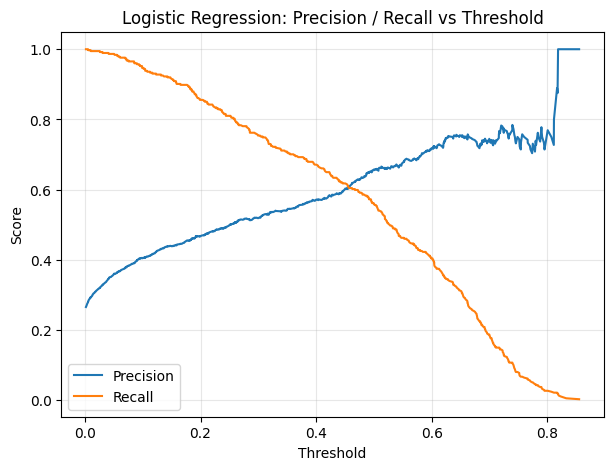

In [15]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(thresholds_pr, precisions[:-1], label="Precision")
plt.plot(thresholds_pr, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression: Precision / Recall vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 7. 模型二：Random Forest(進階)

換一種演算法建立第二個模型,並重複「取得機率 → 選 threshold → 計算指標」的流程


In [16]:
model_rf = RandomForestClassifier(
    n_estimators=300,     # 可調整
    max_depth=None,        # 可調整:嘗試限制深度(例如 8),觀察是否能減少過擬合
    random_state=RANDOM_STATE,
    class_weight=None      # 可調整:改成 "balanced" 試試看對 Recall 的影響
)
model_rf.fit(X_train_scaled, y_train)

proba_rf = model_rf.predict_proba(X_val_scaled)[:, 1]
proba_rf[:10]


array([0.        , 0.74      , 0.08333333, 0.31666667, 0.01333333,
       0.36333333, 0.37333333, 0.07      , 0.01      , 0.48666667])

為 Random Forest 找一個合適的 threshold:這裡示範用「F1-Score 最大化」的方式,在多組 threshold 中挑出 F1 最高的一組,
你也可以改用其他策略(例如指定 Recall 至少要達到某個門檻)


In [17]:
candidate_thresholds = np.arange(0.1, 0.91, 0.05)
best_t, best_f1 = 0.5, -1

for t in candidate_thresholds:
    y_pred_t = (proba_rf >= t).astype(int)
    f1_t = f1_score(y_val, y_pred_t, zero_division=0)
    if f1_t > best_f1:
        best_f1, best_t = f1_t, t

print(f"F1 最高的 threshold ≈ {best_t:.2f}(F1 = {best_f1:.4f})")


F1 最高的 threshold ≈ 0.20(F1 = 0.6138)


In [18]:
res_rf_best = evaluate_threshold(y_val, proba_rf, threshold=best_t, model_name="Random Forest")
results.append(res_rf_best)

# 也保留 threshold = 0.5 作為對照
res_rf_05 = evaluate_threshold(y_val, proba_rf, threshold=0.5, model_name="Random Forest")
results.append(res_rf_05)


===== Random Forest | Threshold = 0.20 =====
Confusion Matrix:
[[684 351]
 [ 53 321]]
  TN=684  FP=351
  FN=53  TP=321
Accuracy : 0.7133
Precision: 0.4777
Recall   : 0.8583
F1-Score : 0.6138

===== Random Forest | Threshold = 0.50 =====
Confusion Matrix:
[[926 109]
 [184 190]]
  TN=926  FP=109
  FN=184  TP=190
Accuracy : 0.7921
Precision: 0.6355
Recall   : 0.5080
F1-Score : 0.5646



## 8. 兩模型比較

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df[["model", "threshold", "accuracy", "precision", "recall", "f1"]]
results_df.round(4)


,model,threshold,accuracy,precision,recall,f1
0,Logistic Regression,0.5,0.8055,0.6572,0.5588,0.6040
1,Logistic Regression,0.3,0.7495,0.5193,0.7540,0.6150
2,Random Forest,0.2,0.7133,0.4777,0.8583,0.6138
3,Random Forest,0.5,0.7921,0.6355,0.5080,0.5646


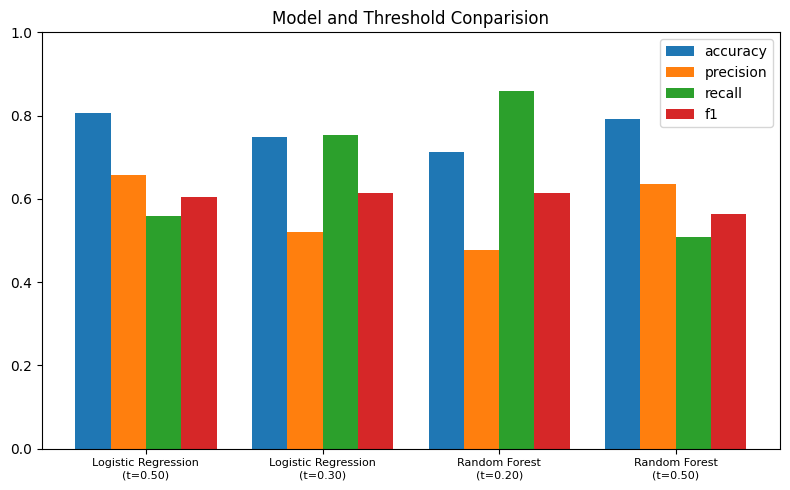

In [20]:
# 視覺化比較(可調整:改成其他你想呈現的圖表)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(["accuracy", "precision", "recall", "f1"]):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(
    [f"{r.model}\n(t={r.threshold:.2f})" for r in results_df.itertuples()],
    fontsize=8
)
ax.legend()
ax.set_ylim(0, 1)
ax.set_title("Model and Threshold Conparision")
plt.tight_layout()
plt.show()


## 9. 結果討論(請依實際執行結果填寫)

> `# TODO`：以下為引導性問題與草稿架構,請依照你實際跑出來的數字填入,不要直接照抄。

**1. 兩個模型在 Precision 與 Recall 上的差異?**

- Logistic Regression 在 threshold=____ 時:Precision=____、Recall=____
- Random Forest 在 threshold=____ 時:Precision=____、Recall=____
- 比較兩者:哪一個模型的 Recall 較高?代表它比較擅長「抓出真正會流失的客戶」;哪一個 Precision 較高?代表它「預測為流失時,判斷比較準」。

**2. 哪一類錯誤(False Positive / False Negative)較多?代表什麼意義?**

- False Negative(實際會流失,但模型預測不會流失):這類客戶會被公司忽略,可能造成實際業績損失,通常是流失預測中「比較不能接受」的錯誤。
- False Positive(實際不會流失,但模型預測會流失):公司可能會多花行銷/挽留成本在不需要挽留的客戶身上,成本相對較低。
- 從你的 Confusion Matrix 中,比較 FN 與 FP 的數量,說明哪個模型、哪個 threshold 下,FN 的比例較低(較適合用於「盡量不漏抓流失客戶」的商業情境)。

**3. 調整 Threshold 帶來的影響**

- 降低 threshold → Recall 通常上升、Precision 通常下降(反之亦然),請用你自己 0.5 與調整後 threshold 的實際數字說明這個 trade-off。


# Quiz 2 深度學習信用卡違約預測

> 資料集：[Default of Credit Card Clients (Kaggle)](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

## 0. 環境設定與資料集準備

In [21]:
import os, glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# 隨機種子（檢查結果的穩定性）
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用裝置:", device)

使用裝置: cuda


In [22]:
CSV_NAME = "UCI_Credit_Card.csv"

def find_csv():
    # 方式 1:kagglehub
    try:
        try:
            import kagglehub
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
            import kagglehub
        folder = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
        found = glob.glob(os.path.join(folder, "*.csv"))
        if found:
            print("kagglehub 下載成功:", found[0])
            return found[0]
    except Exception as e:
        print("kagglehub 下載失敗,改用手動上傳。原因:", repr(e)[:200])
    # 方式 2:手動上傳
    from google.colab import files
    uploaded = files.upload()
    return list(uploaded.keys())[0]

df = find_csv()
df = pd.read_csv(df)
print("\n資料形狀:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
kagglehub 下載成功: /kaggle/input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv

資料形狀: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [23]:
# 目標欄位：下個月是否違約 (1=違約, 0=未違約)
TARGET = "default.payment.next.month"
print(df[TARGET].value_counts())
print("\n違約比例: {:.2%}".format(df[TARGET].mean()))
print("缺失值總數:", int(df.isna().sum().sum()))

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

違約比例: 22.12%
缺失值總數: 0


## 1. 資料前處理與 Feature Scaling

處理重點：
- 移除無預測意義的 `ID` 欄位
- 清理類別欄位中不在說明文件內的值（`EDUCATION` 的 0/5/6、`MARRIAGE` 的 0）
- （可選）對 `SEX / EDUCATION / MARRIAGE` 做 One-Hot Encoding
- 切分 **Train / Validation / Test = 70% / 15% / 15%**（使用 stratify 保持違約比例一致）
- 使用 **StandardScaler**（平均 0、標準差 1）進行 Feature Scaling
  - ⚠️ 只用 **Train** 來 `fit`，再套用到 Validation / Test，避免資料洩漏 (data leakage)

In [24]:
# 是否對類別欄位做 One-Hot
USE_ONEHOT = True

data = df.copy()
data = data.drop(columns=["ID"])
data["EDUCATION"] = data["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
data["MARRIAGE"] = data["MARRIAGE"].replace({0: 3})

if USE_ONEHOT:
    data = pd.get_dummies(data, columns=["SEX", "EDUCATION", "MARRIAGE"], dtype=float)

feature_names = [c for c in data.columns if c != TARGET]
X = data[feature_names].values.astype("float32")
y = data[TARGET].values.astype("float32")

# 切分比例（此處 70 / 15 / 15）
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# 可換成 MinMaxScaler() 試試不同的縮放方式
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_val = scaler.transform(X_val).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

print("特徵數量:", X_train.shape[1])
print("Train / Val / Test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Scaling 後 Train 平均(前3欄):", X_train.mean(axis=0)[:3].round(3))
print("Scaling 後 Train 標準差(前3欄):", X_train.std(axis=0)[:3].round(3))

特徵數量: 29
Train / Val / Test: 21000 4500 4500
Scaling 後 Train 平均(前3欄): [ 0.  0. -0.]
Scaling 後 Train 標準差(前3欄): [1. 1. 1.]


## 2. 超參數設定（基礎版）

| 超參數 | 說明 |
|---|---|
| Epochs | 完整看過整份訓練資料的次數（至少 50） |
| Batch Size | 每次更新權重使用的樣本數 |
| Learning Rate | 每次梯度更新的步伐大小 |
| Optimizer | 權重更新演算法（此處使用 Adam） |
| Hidden Layers / Neurons | 隱藏層層數與每層神經元數量 |

In [25]:
baseline_cfg = {
    "epochs": 50,              # 至少 50
    "batch_size": 128,            # 例如 64 / 128 / 256 / 512
    "lr": 1e-3,                # 例如 1e-2 / 1e-3 / 1e-4
    "optimizer": "adam",          # "adam" / "sgd" / "rmsprop"
    "hidden_layers": [64, 32],      # 例如 [128, 64, 32]、[32]、[256, 128]
    "dropout": 0.0,            # 基礎版不使用 Dropout
    "weight_decay": 0.0,          # 基礎版不使用 L2
    "early_stopping": False,      # 基礎版不使用 Early Stopping
    "patience": 10,
}
baseline_cfg

{'epochs': 50,
 'batch_size': 128,
 'lr': 0.001,
 'optimizer': 'adam',
 'hidden_layers': [64, 32],
 'dropout': 0.0,
 'weight_decay': 0.0,
 'early_stopping': False,
 'patience': 10}

## 3. 建立 MLP 與訓練函式

In [26]:
class MLP(nn.Module):
    # 多層感知機：[Linear -> ReLU -> (Dropout)] x N -> Linear(1)
    # 輸出為 logit，搭配 BCEWithLogitsLoss（內含 sigmoid）
    def __init__(self, in_dim, hidden_layers, dropout=0.0):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def get_optimizer(name, params, lr, weight_decay):
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)   # weight_decay 即 L2 正則化
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError("未知的 optimizer: " + name)


criterion = nn.BCEWithLogitsLoss()
# 資料類別不平衡（違約約 22%），可改用 pos_weight 提高 Recall，例如：
# criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((y_train == 0).sum() / (y_train == 1).sum()))


@torch.no_grad()
def evaluate(model, X, y):
    # 回傳 loss 與預測機率
    model.eval()
    xt = torch.from_numpy(X).to(device)
    yt = torch.from_numpy(y).to(device)
    logits = model(xt)
    loss = criterion(logits, yt).item()
    probs = torch.sigmoid(logits).cpu().numpy()
    return loss, probs


def train_model(cfg):
    set_seed(SEED)
    model = MLP(X_train.shape[1], cfg["hidden_layers"], cfg["dropout"]).to(device)
    optimizer = get_optimizer(cfg["optimizer"], model.parameters(), cfg["lr"], cfg["weight_decay"])
    train_loader = make_loader(X_train, y_train, cfg["batch_size"], shuffle=True)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
            n += len(xb)
        train_loss = running / n
        val_loss, val_probs = evaluate(model, X_val, y_val)
        val_acc = accuracy_score(y_val, val_probs >= 0.5)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

        # Early Stopping：val_loss 連續 patience 個 epoch 沒有進步就停止，並還原最佳權重
        if cfg["early_stopping"]:
            if val_loss < best_val - 1e-4:
                best_val, wait = val_loss, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= cfg["patience"]:
                    print(f"⏹ Early stopping 於 epoch {epoch}（最佳 epoch = {epoch - wait}）")
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def compute_metrics(y_true, probs, threshold=0.5):
    # threshold 預設 0.5；降低（如 0.3）通常可提高 Recall、降低 Precision
    pred = (probs >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1-Score": f1_score(y_true, pred, zero_division=0),
    }


def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.show()

## 4. 基礎模型訓練 & Loss 曲線

Epoch   1 | train_loss=0.5077 | val_loss=0.4656 | val_acc=0.8051
Epoch  10 | train_loss=0.4261 | val_loss=0.4392 | val_acc=0.8173
Epoch  20 | train_loss=0.4177 | val_loss=0.4382 | val_acc=0.8158
Epoch  30 | train_loss=0.4110 | val_loss=0.4421 | val_acc=0.8151
Epoch  40 | train_loss=0.4042 | val_loss=0.4477 | val_acc=0.8140
Epoch  50 | train_loss=0.3979 | val_loss=0.4484 | val_acc=0.8127


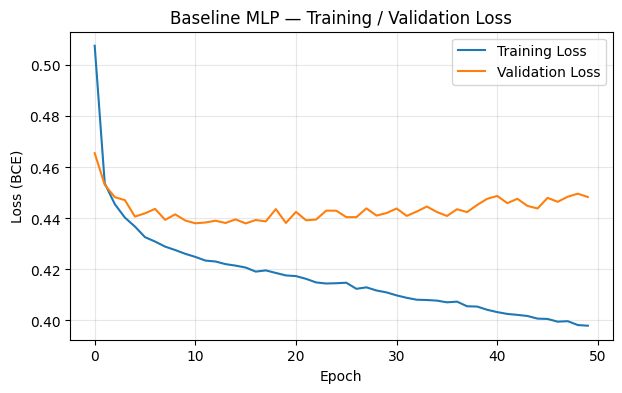

In [27]:
base_model, base_hist = train_model(baseline_cfg)
plot_history(base_hist, "Baseline MLP — Training / Validation Loss")

## 6. 預測 Validation Dataset 中的一筆 Sample

程式會取出 Validation Set 的一筆資料，輸出模型預測的違約機率、預測類別與真實標籤。

In [28]:
# 想看 Validation 中第幾筆（0 ~ len(X_val)-1）
SAMPLE_IDX = 15

def predict_one(model, idx):
    model.eval()
    x = torch.from_numpy(X_val[idx:idx + 1]).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    pred = int(prob >= 0.5)
    true = int(y_val[idx])
    print(f"Validation 第 {idx} 筆")
    print(f"  預測違約機率 : {prob:.4f}")
    print(f"  預測類別     : {pred}  ({'違約' if pred else '未違約'})")
    print(f"  真實類別     : {true}  ({'違約' if true else '未違約'})")
    print("  預測結果     :", "✅ 正確" if pred == true else "❌ 錯誤")

predict_one(base_model, SAMPLE_IDX)


Validation 第 15 筆
  預測違約機率 : 0.7521
  預測類別     : 1  (違約)
  真實類別     : 0  (未違約)
  預測結果     : ❌ 錯誤


## 7. 進階：模型改善策略

針對基礎 MLP，同時加入三種改善策略：

1. **Dropout**：訓練時隨機關閉部分神經元，降低對特定神經元的依賴
2. **L2 Regularization**：透過 optimizer 的 `weight_decay` 懲罰過大的權重
3. **Early Stopping**：Validation Loss 連續 `patience` 個 epoch 無進步就停止，並還原最佳權重

> 💡 想做「單一策略」的對照實驗（更能說明每個策略的效果），可以只開其中一項，例如只把
> `dropout` 設為 0.3，其餘保持基礎值，再重新執行。

Epoch   1 | train_loss=0.5988 | val_loss=0.5263 | val_acc=0.7789
Epoch  10 | train_loss=0.4556 | val_loss=0.4514 | val_acc=0.8144
Epoch  20 | train_loss=0.4481 | val_loss=0.4434 | val_acc=0.8142
Epoch  30 | train_loss=0.4442 | val_loss=0.4396 | val_acc=0.8173
Epoch  40 | train_loss=0.4391 | val_loss=0.4379 | val_acc=0.8187
Epoch  50 | train_loss=0.4371 | val_loss=0.4367 | val_acc=0.8191
Epoch  60 | train_loss=0.4356 | val_loss=0.4361 | val_acc=0.8187
Epoch  70 | train_loss=0.4352 | val_loss=0.4360 | val_acc=0.8187
Epoch  80 | train_loss=0.4328 | val_loss=0.4354 | val_acc=0.8196
⏹ Early stopping 於 epoch 88（最佳 epoch = 78）


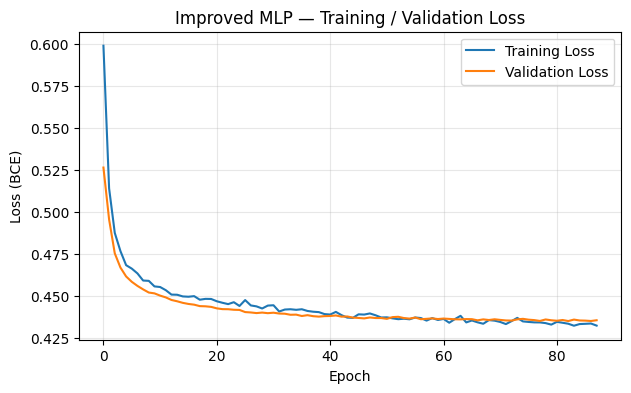

In [29]:
# 進階版超參數
improved_cfg = {
    "epochs": 100,                # 上限拉高，讓 Early Stopping 決定何時停止
    "batch_size": 256,
    "lr": 5e-4,                   # 可嘗試 5e-4 等
    "optimizer": "adam",              # 可嘗試 "sdg" / "rmsprop"
    "hidden_layers": [64, 32],          # 可調整結構，如 [128, 64]
    "dropout": 0.3,                #  Dropout 機率  例如 0.2 ~ 0.5
    "weight_decay": 1e-3,            #  L2 強度 例如 1e-5 ~ 1e-3
    "early_stopping": True,           #  設為 False 可關閉
    "patience": 10,               #  例如 5 ~ 15
}
imp_model, imp_hist = train_model(improved_cfg)
plot_history(imp_hist, "Improved MLP — Training / Validation Loss")

In [30]:
print("=== 改善後模型：預測同一筆 Validation Sample ===")
predict_one(imp_model, SAMPLE_IDX)

=== 改善後模型：預測同一筆 Validation Sample ===
Validation 第 15 筆
  預測違約機率 : 0.6611
  預測類別     : 1  (違約)
  真實類別     : 0  (未違約)
  預測結果     : ❌ 錯誤


## 8. 改善前後比較

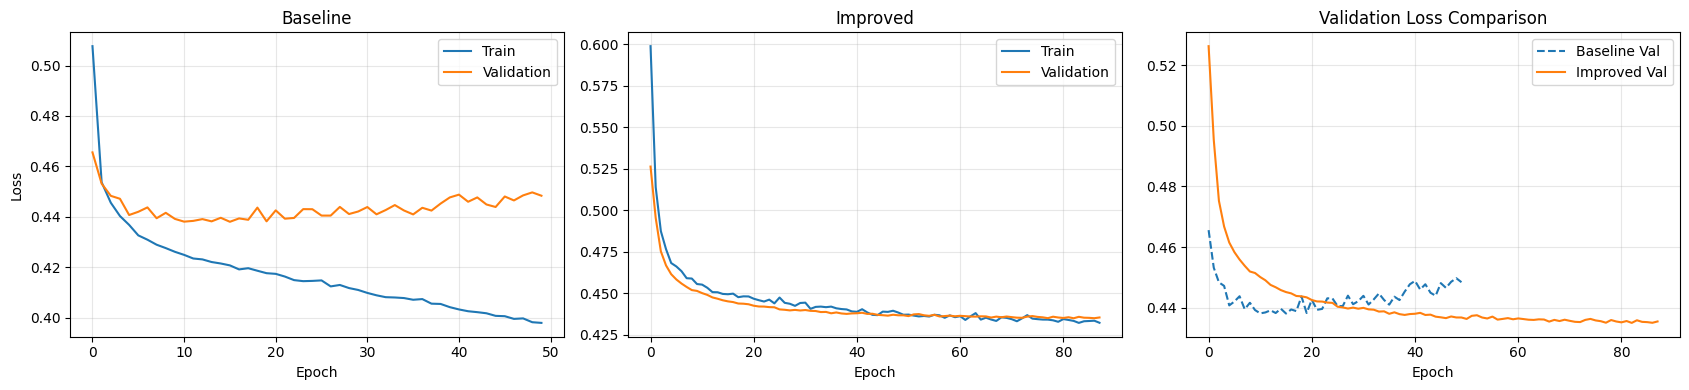

In [31]:
# --- 8.1 Loss 曲線比較 ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(base_hist["train_loss"], label="Train")
axes[0].plot(base_hist["val_loss"], label="Validation")
axes[0].set_title("Baseline"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(imp_hist["train_loss"], label="Train")
axes[1].plot(imp_hist["val_loss"], label="Validation")
axes[1].set_title("Improved"); axes[1].set_xlabel("Epoch")

axes[2].plot(base_hist["val_loss"], label="Baseline Val", linestyle="--")
axes[2].plot(imp_hist["val_loss"], label="Improved Val")
axes[2].set_title("Validation Loss Comparison"); axes[2].set_xlabel("Epoch")

for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [32]:
# --- 8.2 指標比較（Validation 與 Test）---
rows = {}
for name, model in [("Baseline", base_model), ("Improved", imp_model)]:
    v_loss, v_probs = evaluate(model, X_val, y_val)
    t_loss, t_probs = evaluate(model, X_test, y_test)
    rows[(name, "Validation")] = {"Loss": v_loss, **compute_metrics(y_val, v_probs)}
    rows[(name, "Test")] = {"Loss": t_loss, **compute_metrics(y_test, t_probs)}

result_df = pd.DataFrame(rows).T.round(4)
result_df.index.names = ["Model", "Dataset"]
result_df

Loss  Accuracy  Precision  Recall  F1-Score
Model    Dataset                                                  
Baseline Validation  0.4484    0.8127     0.6238  0.3849    0.4761
         Test        0.4466    0.8102     0.6127  0.3876    0.4748
Improved Validation  0.4350    0.8198     0.6783  0.3518    0.4633
         Test        0.4355    0.8184     0.6758  0.3454    0.4571

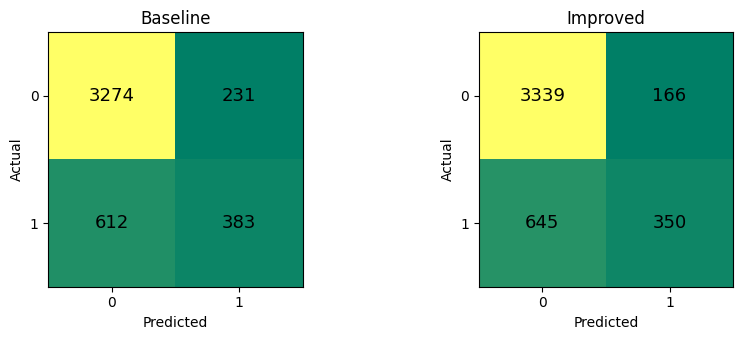

In [33]:
# --- 8.3 Confusion Matrix（Validation）---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (name, model) in zip(axes, [("Baseline", base_model), ("Improved", imp_model)]):
    _, probs = evaluate(model, X_val, y_val)
    cm = confusion_matrix(y_val, (probs >= 0.5).astype(int))
    ax.imshow(cm, cmap="summer")
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
plt.tight_layout(); plt.show()

In [34]:
# --- 8.4 自動摘要：過擬合程度 / 最佳 epoch / 穩定度 ---
def summarize(name, h):
    best_ep = int(np.argmin(h["val_loss"])) + 1
    gap = h["val_loss"][-1] - h["train_loss"][-1]
    last10_std = float(np.std(h["val_loss"][-10:]))
    print(f"[{name}]")
    print(f"  實際訓練 epoch 數           : {len(h['val_loss'])}")
    print(f"  Val Loss 最低點 (epoch)     : {best_ep}  (val_loss={min(h['val_loss']):.4f})")
    print(f"  最後 epoch 的 Val - Train   : {gap:+.4f}   (越大代表 overfitting 越明顯)")
    print(f"  最後 10 epoch Val Loss 標準差: {last10_std:.4f}   (越小越穩定)")

summarize("Baseline", base_hist)
summarize("Improved", imp_hist)

[Baseline]
  實際訓練 epoch 數           : 50
  Val Loss 最低點 (epoch)     : 16  (val_loss=0.4380)
  最後 epoch 的 Val - Train   : +0.0504   (越大代表 overfitting 越明顯)
  最後 10 epoch Val Loss 標準差: 0.0018   (越小越穩定)
[Improved]
  實際訓練 epoch 數           : 88
  Val Loss 最低點 (epoch)     : 83  (val_loss=0.4350)
  最後 epoch 的 Val - Train   : +0.0032   (越大代表 overfitting 越明顯)
  最後 10 epoch Val Loss 標準差: 0.0003   (越小越穩定)


## 9. 觀察與結論

### 9.1 超參數說明
- **Epoch**：基礎版 50、進階版最多 100（由 Early Stopping 決定實際停止時間）
- **Batch Size**：256，兼顧訓練速度與梯度穩定性
- **Learning Rate**：1e-3，Adam 的常用預設值
- **Optimizer**：Adam，收斂快且對學習率較不敏感 (其他兩個模型效果沒有比較好)
- **Hidden Layer / Neuron**：2 層隱藏層，64 → 32；輸入約 30 個特徵，輸出 1 個 logit（違約機率）

### 9.2 改善前後觀察

**a. 是否改善 Overfitting？** 有明顯改善
- Baseline 的 Training Loss 持續下降（0.5077 → 0.3979），但 Validation Loss 在第 16 epoch 達到最低 0.4380 後回升，最終為 0.4484。最後一個 epoch 的 Val − Train 差距為 +0.0504
- Improved 的 Val − Train 差距縮小為 +0.0032，且 Validation Loss 沒有回升。

**b. Validation Loss 是否下降？** 是
- Validation Loss 由 0.4484 降至 0.4350。
- 即使與 Baseline 自己的最低點 0.4380 相比，仍低 0.0030。
- Test Loss 也由 0.4466 降至 0.4355，結果一致。

**c. 模型是否更穩定？** 是，最後 10 個 epoch 的 Validation Loss 標準差由 0.0018 降至 0.0003。Improved 由 Early Stopping 在第 88 epoch 停止，並還原第 83 epoch 的最佳權重。

**>> 綜合說明**
- 改善策略有效降低 overfitting，讓 Loss 更低、更穩定，Accuracy 與 Precision 也提升。
- Recall 與 F1 下降，是因為正則化讓模型預測更保守。資料中違約僅約 22%，分類門檻又固定為 0.5，對少數類別不利
- 這代表機率預測品質變好，但 0.5 的門檻不再適合，可用調整 threshold 或 `pos_weight` 改善

# Quiz 3 模型表現評估

## 0. 環境與資料前處理（與 Quiz 2 相同）

In [35]:
import os, glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# 與 Quiz 2 相同，才能使用「相同的 Training / Validation Dataset」
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用裝置:", device)

使用裝置: cuda


In [36]:
TARGET = "default.payment.next.month"
USE_ONEHOT = True

def find_csv():
    # 方式 1: 優先嘗試透過 kagglehub 下載
    try:
        try:
            import kagglehub
        except ImportError:
            print("正在安裝 kagglehub...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
            import kagglehub

        print("正在下載資料集...")
        folder = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
        found = glob.glob(os.path.join(folder, "*.csv"))
        if found:
            print("kagglehub 下載成功:", found[0])
            return found[0]
    except Exception as e:
        print("kagglehub 下載失敗，改用手動上傳。原因:", repr(e)[:200])

    # 方式 2: Colab 手動上傳備援
    try:
        from google.colab import files
        print("請手動上傳 UCI_Credit_Card.csv 檔案：")
        uploaded = files.upload()
        return list(uploaded.keys())[0]
    except ImportError:
        # 非 Colab 環境且本地若有同名檔案
        default_path = "UCI_Credit_Card.csv"
        if os.path.exists(default_path):
            return default_path
        raise FileNotFoundError("無法透過 kagglehub 下載，且當前路徑下未找到 UCI_Credit_Card.csv。")

# 1. 取得資料路徑並讀取
DATA_PATH = find_csv()
df = pd.read_csv(DATA_PATH)
print("\n資料形狀:", df.shape)

# 2. 資料清洗與前處理
data = df.drop(columns=["ID"]).copy()
data["EDUCATION"] = data["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
data["MARRIAGE"] = data["MARRIAGE"].replace({0: 3})

if USE_ONEHOT:
    data = pd.get_dummies(data, columns=["SEX", "EDUCATION", "MARRIAGE"], dtype=float)

# 3. 切分特徵 (X) 與標籤 (y)
feature_names = [c for c in data.columns if c != TARGET]
X = data[feature_names].values.astype("float32")
y = data[TARGET].values.astype("float32")

# 4. 切分 Train (70%) / Val (15%) / Test (15%)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

# 5. 特徵標準化 (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_val = scaler.transform(X_val).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

# 6. 輸出檢查資訊
print("特徵維度 (Features count):", X_train.shape[1])
print("Train / Val / Test 樣本數:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Validation 違約比例: {:.2%}".format(y_val.mean()))

正在下載資料集...
Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
kagglehub 下載成功: /kaggle/input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv

資料形狀: (30000, 25)
特徵維度 (Features count): 29
Train / Val / Test 樣本數: 21000 4500 4500
Validation 違約比例: 22.11%


## 1. 重現 Quiz 2 的 MLP

沿用 Quiz 2 的模型定義與訓練流程。這裡同時訓練「基礎版」與「改善版（Dropout + L2 + Early Stopping）」，再用下方的 `MLP_CHOICE` 選擇要拿哪一個來畫 ROC

In [37]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_layers, dropout=0.0):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
                      batch_size=batch_size, shuffle=shuffle)

criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(torch.from_numpy(X).to(device))
    loss = criterion(logits, torch.from_numpy(y).to(device)).item()
    return loss, torch.sigmoid(logits).cpu().numpy()

def train_model(cfg):
    set_seed(SEED)
    model = MLP(X_train.shape[1], cfg["hidden_layers"], cfg["dropout"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    loader = make_loader(X_train, y_train, cfg["batch_size"], shuffle=True)
    best_val, best_state, wait = float("inf"), None, 0
    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        val_loss, _ = evaluate(model, X_val, y_val)
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | val_loss={val_loss:.4f}")
        if cfg["early_stopping"]:
            if val_loss < best_val - 1e-4:
                best_val, wait = val_loss, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= cfg["patience"]:
                    print(f"⏹ Early stopping 於 epoch {epoch}")
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# 需與 Quiz 2 使用相同設定，結果才會一致
baseline_cfg = {"epochs": 50,
          "batch_size": 256,
          "lr": 1e-3,
          "hidden_layers": [64, 32],
          "dropout": 0.0,
          "weight_decay": 0.0,
          "early_stopping": False,
          "patience": 10}
improved_cfg = {"epochs": 100,
          "batch_size": 256,
          "lr": 1e-3,
          "hidden_layers": [64, 32],
          "dropout": 0.3,
          "weight_decay": 1e-4,
          "early_stopping": True,
          "patience": 10}

print("=== 訓練 Baseline MLP ===")
mlp_base = train_model(baseline_cfg)
print("\n=== 訓練 Improved MLP ===")
mlp_imp = train_model(improved_cfg)

=== 訓練 Baseline MLP ===
Epoch   1 | val_loss=0.4908
Epoch  10 | val_loss=0.4393
Epoch  20 | val_loss=0.4387
Epoch  30 | val_loss=0.4400
Epoch  40 | val_loss=0.4438
Epoch  50 | val_loss=0.4468

=== 訓練 Improved MLP ===
Epoch   1 | val_loss=0.4977
Epoch  10 | val_loss=0.4448
Epoch  20 | val_loss=0.4369
Epoch  30 | val_loss=0.4341
Epoch  40 | val_loss=0.4334
Epoch  50 | val_loss=0.4333
⏹ Early stopping 於 epoch 57


##  2.ROC Curve 與 AUC

### 2.1 取得 MLP 對 Validation Dataset 的 Prediction Score / Probability

In [38]:
# 可選擇用哪個 MLP 畫 ROC —— "improved"或 "baseline"
MLP_CHOICE = "improved"

mlp_model = mlp_imp if MLP_CHOICE == "improved" else mlp_base
_, mlp_val_score = evaluate(mlp_model, X_val, y_val)

print("MLP 使用版本:", MLP_CHOICE)
print("Prediction score 形狀:", mlp_val_score.shape)
print("前 10 筆 score  :", np.round(mlp_val_score[:10], 4))
print("前 10 筆真實標籤:", y_val[:10].astype(int))
print("score 範圍: {:.4f} ~ {:.4f}".format(mlp_val_score.min(), mlp_val_score.max()))

MLP 使用版本: improved
Prediction score 形狀: (4500,)
前 10 筆 score  : [0.1834 0.2161 0.1641 0.0906 0.2705 0.0923 0.3445 0.1865 0.0957 0.0886]
前 10 筆真實標籤: [0 1 0 0 0 0 0 0 0 0]
score 範圍: 0.0001 ~ 0.9474


### 2.2 繪製 ROC Curve 並計算 AUC

- X 軸：**FPR**（False Positive Rate）＝ FP / (FP + TN)
- Y 軸：**TPR**（True Positive Rate，即 Recall）＝ TP / (TP + FN)
- `roc_curve` 會自動掃過所有可能的門檻，每個門檻對應曲線上的一個點

MLP AUC (Validation) = 0.7770


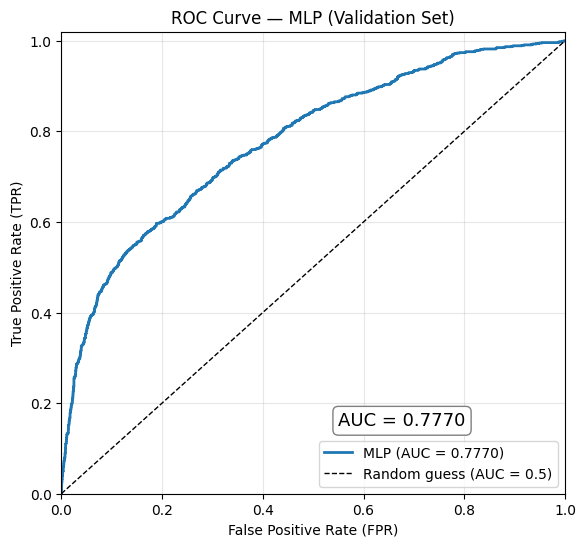

In [39]:
fpr_mlp, tpr_mlp, thr_mlp = roc_curve(y_val, mlp_val_score)
auc_mlp = auc(fpr_mlp, tpr_mlp)

# 交叉驗證：兩種算法應該相同
assert abs(auc_mlp - roc_auc_score(y_val, mlp_val_score)) < 1e-9
print(f"MLP AUC (Validation) = {auc_mlp:.4f}")

plt.figure(figsize=(6.5, 6))
plt.plot(fpr_mlp, tpr_mlp, lw=2, label=f"MLP (AUC = {auc_mlp:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess (AUC = 0.5)")
plt.text(0.55, 0.15, f"AUC = {auc_mlp:.4f}", fontsize=13,
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve — MLP (Validation Set)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

### 2.3 ROC Curve 與 AUC 的意義

**ROC Curve（Receiver Operating Characteristic Curve）**
- 模型會給每位客戶一個「違約機率」，要分成違約／未違約，必須設定一個門檻。
- 門檻不同，FPR 與 TPR 就不同：門檻低 → 抓到較多違約者（TPR 高），但誤判較多（FPR 也高）；門檻高則相反。
- ROC 把**所有門檻**下的 (FPR, TPR) 畫成曲線，展現模型在「抓得到」與「誤判」之間的取捨，且**不依賴單一門檻**（例如 0.5）。
- 曲線越靠近**左上角**越好；對角線代表隨機猜測。

**AUC（Area Under the Curve）**
- ROC 曲線下的面積，範圍 0 ~ 1。
- 意義：**隨機抽一個違約樣本與一個未違約樣本，模型給違約樣本較高分數的機率**。
- AUC = 0.5 → 無區分能力；AUC = 1.0 → 完美區分；AUC < 0.5 → 反向預測。
- 常見參考：0.7 ~ 0.8 尚可、0.8 ~ 0.9 良好、> 0.9 優秀（僅供參考，依領域而定）。
- 優點：對類別不平衡（本資料違約僅約 22%）比 Accuracy 更不容易被誤導。

> ✏️ **請依你實際跑出的 AUC 補一句**：本次 MLP 的 AUC 為 ___，代表它隨機抽一對違約／未違約客戶時，有約 ___% 的機率能把違約客戶的分數排得比較高，區分能力屬於 ___。

## 3. MLP vs. Machine Learning Classification 模型

### 3.1 建立第二個模型

使用**與 Quiz 2 相同的 Training / Validation Dataset**（含相同的 Scaling）。
> `"rf"` Random Forest、`"logreg"` Logistic Regression、`"tree"` Decision Tree、`"knn"` K-Nearest Neighbors。

In [40]:
# 選擇第二個模型
ML_CHOICE = "rf"     # "rf" / "logreg" / "tree" / "knn"

# 各模型超參數
ml_models = {
    "rf":     ("Random Forest",       RandomForestClassifier(n_estimators=300, max_depth=8,min_samples_leaf=20, n_jobs=-1, random_state=SEED)),
    "logreg": ("Logistic Regression", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
    "tree":   ("Decision Tree",       DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=SEED)),
    "knn":    ("KNN (k=25)",          KNeighborsClassifier(n_neighbors=25, n_jobs=-1)),
}
ml_name, ml_model = ml_models[ML_CHOICE]
ml_model.fit(X_train, y_train)

# predict_proba 回傳 [P(class 0), P(class 1)]，取第 2 欄作為 prediction score
ml_val_score = ml_model.predict_proba(X_val)[:, 1]

print("第二個模型:", ml_name)
print("Validation Accuracy (門檻 0.5): {:.4f}".format(accuracy_score(y_val, ml_val_score >= 0.5)))
print("前 10 筆 score  :", np.round(ml_val_score[:10], 4))
print("前 10 筆真實標籤:", y_val[:10].astype(int))

第二個模型: Random Forest
Validation Accuracy (門檻 0.5): 0.8167
前 10 筆 score  : [0.2021 0.3056 0.1948 0.0756 0.1151 0.1551 0.3306 0.1817 0.1224 0.0772]
前 10 筆真實標籤: [0 1 0 0 0 0 0 0 0 0]


### 3.2 兩個模型的 ROC Curve 畫在同一張圖，並標示 AUC

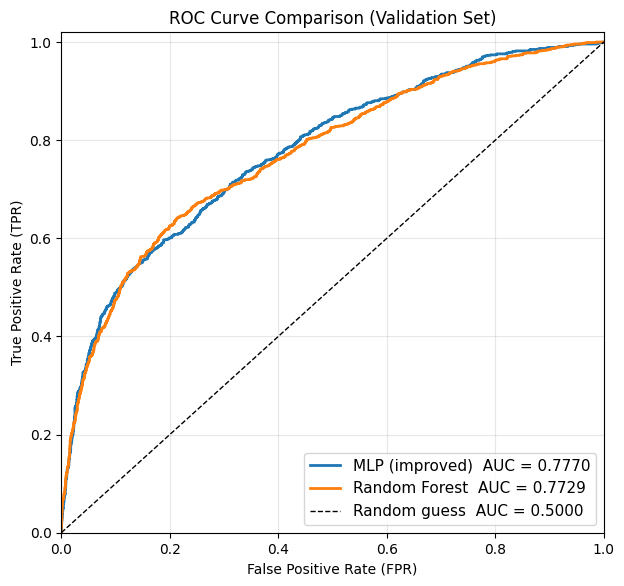

In [41]:
fpr_ml, tpr_ml, _ = roc_curve(y_val, ml_val_score)
auc_ml = auc(fpr_ml, tpr_ml)

mlp_label = f"MLP ({MLP_CHOICE})"
plt.figure(figsize=(7, 6.5))
plt.plot(fpr_mlp, tpr_mlp, lw=2, color="tab:blue",   label=f"{mlp_label}  AUC = {auc_mlp:.4f}")
plt.plot(fpr_ml,  tpr_ml,  lw=2, color="tab:orange", label=f"{ml_name}  AUC = {auc_ml:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess  AUC = 0.5000")
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison (Validation Set)")
plt.legend(loc="lower right", fontsize=11); plt.grid(alpha=0.3)
plt.show()

In [42]:
# --- AUC 比較表（Validation；另附 Test 作為參考，不影響結論）---
_, mlp_test_score = evaluate(mlp_model, X_test, y_test)
ml_test_score = ml_model.predict_proba(X_test)[:, 1]

auc_table = pd.DataFrame({
    "Model": [mlp_label, ml_name],
    "AUC (Validation)": [auc_mlp, auc_ml],
    "AUC (Test, 參考)": [roc_auc_score(y_test, mlp_test_score), roc_auc_score(y_test, ml_test_score)],
}).round(4)
auc_table

,Model,AUC (Validation),"AUC (Test, 參考)"
0,MLP (improved),0.7770,0.7736
1,Random Forest,0.7729,0.7768


In [43]:
# --- (選做) Bootstrap 檢查 AUC 差異是否只是抽樣造成 ---
# 對 Validation 重複抽樣 1000 次，計算兩模型 AUC 差 (MLP - ML) 的 95% 信賴區間
# ✏️ 可修改：N_BOOT 次數（越大越穩、越慢）
N_BOOT = 1000
rng = np.random.default_rng(SEED)
n = len(y_val)
diffs = []
for _ in range(N_BOOT):
    idx = rng.integers(0, n, n)
    if len(np.unique(y_val[idx])) < 2:
        continue
    diffs.append(roc_auc_score(y_val[idx], mlp_val_score[idx]) - roc_auc_score(y_val[idx], ml_val_score[idx]))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"AUC 差 (MLP - {ml_name}) = {auc_mlp - auc_ml:+.4f}，95% CI = [{lo:+.4f}, {hi:+.4f}]")
print("→ 區間包含 0：兩者差異不顯著" if lo <= 0 <= hi else "→ 區間不含 0：差異具統計上的穩定性")

AUC 差 (MLP - Random Forest) = +0.0042，95% CI = [-0.0034, +0.0122]
→ 區間包含 0：兩者差異不顯著


In [44]:
# --- 自動摘要 ---
better = mlp_label if auc_mlp > auc_ml else ml_name
print(f"{mlp_label:>22s} AUC = {auc_mlp:.4f}")
print(f"{ml_name:>22s} AUC = {auc_ml:.4f}")
print(f"AUC 較高者（正負樣本區分能力較好）: {better}，差距 {abs(auc_mlp - auc_ml):.4f}")

# 在幾個固定 FPR 下比較 TPR，看兩條曲線是否有交叉
for f in [0.05, 0.1, 0.2, 0.3, 0.5]:
    t1 = np.interp(f, fpr_mlp, tpr_mlp)
    t2 = np.interp(f, fpr_ml, tpr_ml)
    print(f"FPR={f:.2f} → TPR: MLP={t1:.3f} | {ml_name}={t2:.3f}")

        MLP (improved) AUC = 0.7770
         Random Forest AUC = 0.7729
AUC 較高者（正負樣本區分能力較好）: MLP (improved)，差距 0.0042
FPR=0.05 → TPR: MLP=0.360 | Random Forest=0.346
FPR=0.10 → TPR: MLP=0.488 | Random Forest=0.474
FPR=0.20 → TPR: MLP=0.601 | Random Forest=0.625
FPR=0.30 → TPR: MLP=0.695 | Random Forest=0.698
FPR=0.50 → TPR: MLP=0.846 | Random Forest=0.826


### 3.3 比較與結論

> ✏️ **請依實際跑出的數字修改以下內容**（此處為撰寫方向）。

**ROC Curve 比較**
- 兩條曲線是否有交叉？若一條在幾乎所有 FPR 下都位於另一條上方，代表它在各種門檻下都較佳。
- 在低 FPR 區間（例如 FPR ≤ 0.2，代表少誤判好客戶）誰的 TPR 較高？這對銀行實務通常更重要。

**AUC 比較**
- MLP AUC = ___；第二個模型 AUC = ___；差距 = ___。
- AUC 較高者為 ___，代表它把違約客戶排在未違約客戶前面的機率較高，**正負樣本區分能力較好**。
- 若 Bootstrap 95% CI 包含 0，應說明「兩者差距很小，實務上表現接近」；若不含 0，可說明差距具穩定性。

**可能原因（依結果擇一撰寫）**
- 本資料集為中小型表格資料（3 萬筆、約 30 特徵），樹類模型（Random Forest）常能捕捉特徵間的非線性與交互作用，通常與 MLP 相當甚至略高。
- Logistic Regression 為線性模型，若 AUC 與 MLP 接近，代表資料的線性可分程度已相當高。
- MLP 結果會受初始化、正則化與 Early Stopping 影響，隨機種子不同可能有小幅波動。

**補充**：AUC 衡量的是「排序能力」，與門檻無關；實際部署仍需依 Precision / Recall 需求選擇分類門檻。
